## Install library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

## Membaca Data

In [23]:
df = pd.read_csv("data/supply_chain_logistic.csv", sep=";")

print(df.shape)
df.head()

(32065, 5)


,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,40.375.568.475.194.900,-770.143.177.425.258,5.136.511.864.928.780,5.927.585.801.443.970,11.821.159.890.280.700
1,3.350.781.833.905.290,-11.703.690.240.506.400,5.101.511.530.652.880,15.919.921.912.280.300,961.198.830.435.769
2,30.020.639.789.030.900,-752.692.240.366.282,5.090.802.620.415.410,8.787.765.349.367.670,6.570.431.288.350.110
3,36.649.222.512.758.900,-7.019.052.930.366.370,8.219.557.503.166.250,0.04525714813036494,0.5489520412771786
4,30.001.279.284.395.600,-7.001.219.476.429.300,5.000.074.881.555.600,8.004.850.904.938.760,8.861.442.874.133.280


## Deskripsi Variabel dan Tipe Data (Skala Pengukuran)

Berikut penjabaran tipe data dan skala pengukuran untuk setiap kolom pada dataset `supply_chain_logistic.csv`:

| Kolom | Tipe Data | Skala Pengukuran | Keterangan |
|---|---|---|---|
| latitude | Numerik (float) | Rasio | Koordinat lokasi pengiriman |
| longitude | Numerik (float) | Rasio | Koordinat lokasi pengiriman |
| penggunaan_bbm | Numerik (float) | Rasio | Konsumsi bahan bakar, memiliki titik nol mutlak (0 = tidak ada penggunaan BBM) |
| tingkat_kemacetan | Numerik (float, dalam praktik digunakan sebagai indeks kontinu) | Rasio/Interval | Indeks kemacetan jalur, semakin tinggi nilai = semakin macet |
| risiko_pengiriman | Numerik (float, indeks risiko) | Rasio/Interval | Indeks risiko pengiriman pada rute/titik tersebut |

**Catatan skala:**
- Semua variabel numerik di atas berskala **rasio** karena memiliki titik nol yang bermakna (nol = tidak ada/baseline) dan selisih antar nilai dapat diinterpretasikan secara konsisten.
- Variabel `tingkat_kemacetan` dan `risiko_pengiriman` merupakan indeks komposit, sehingga walaupun secara teknis numerik rasio, interpretasinya lebih dekat ke **indeks ordinal yang diperhalus menjadi kontinu** (semakin tinggi semakin buruk/berisiko).
- Tidak ada variabel kategorik (nominal/ordinal) yang digunakan langsung dalam proses optimasi pada notebook ini.

## Mengubah tipe data longitude dan latitude menjadi string

In [24]:
df['latitude'] = df['latitude'].astype(str).str.replace('.', '', regex=False)
df['longitude'] = df['longitude'].astype(str).str.replace('.', '', regex=False)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df['latitude'] = df['latitude'] / 1e15
df['longitude'] = df['longitude'] / 1e15

In [25]:
df[['latitude','longitude']].describe()

,latitude,longitude
count,32065.000000,32065.000000
mean,16.367940,-7.846881
std,16.413666,3.281024
min,0.000333,-12.000000
25%,3.503354,-10.307297
50%,4.714683,-8.063714
75%,30.979284,-7.055771
max,50.000000,-0.000703


In [7]:
df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,40.375568,-0.770143,5.136.511.864.928.780,5.927.585.801.443.970,11.821.159.890.280.700
1,3.350782,-11.703690,5.101.511.530.652.880,15.919.921.912.280.300,961.198.830.435.769
2,30.020640,-0.752692,5.090.802.620.415.410,8.787.765.349.367.670,6.570.431.288.350.110
3,36.649223,-7.019053,8.219.557.503.166.250,0.04525714813036494,0.5489520412771786
4,30.001279,-7.001219,5.000.074.881.555.600,8.004.850.904.938.760,8.861.442.874.133.280


## Cleaning

In [26]:
columns_to_scale = [
    'penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman'
]

for col in columns_to_scale:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

df = df.dropna()

## Normalisasi

In [27]:
scaler = MinMaxScaler()

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,40.375568,-0.770143,0.064224,0.074120,0.147798
1,3.350782,-11.703690,0.063787,0.199098,0.012017
2,30.020640,-0.752692,0.063653,0.109893,0.082148
3,36.649223,-7.019053,0.102773,0.056586,0.068634
4,30.001279,-7.001219,0.062518,0.100101,0.110793


# **EDA**

## **Statistik Deskriptif**

In [18]:
df[['penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman']].describe()

,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
count,32065,32065,32065
unique,32029,32064,32065
top,5.0,"1,51E+11",11.821.159.890.280.700
freq,20,2,1


## **Distribusi Variabel**

In [28]:
df_eda = df.sample(
    n=50,
    random_state=42)

print(df_eda.shape)

(50, 5)


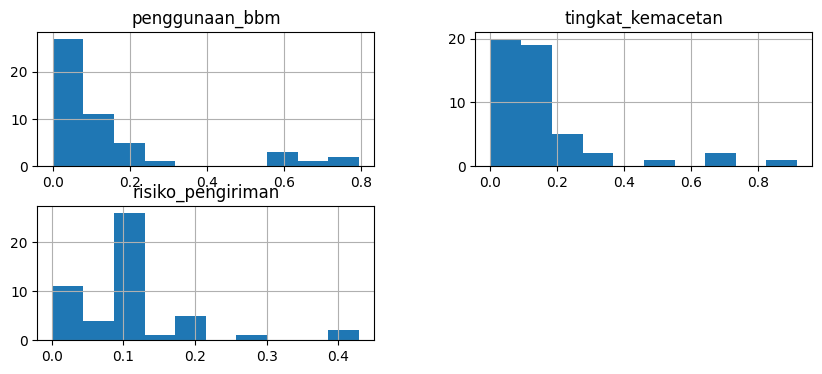

In [29]:
df_eda[
    [
        'penggunaan_bbm',
        'tingkat_kemacetan',
        'risiko_pengiriman'
    ]
].hist(
    figsize=(10,4)
)

plt.show()

## **Boxplot**

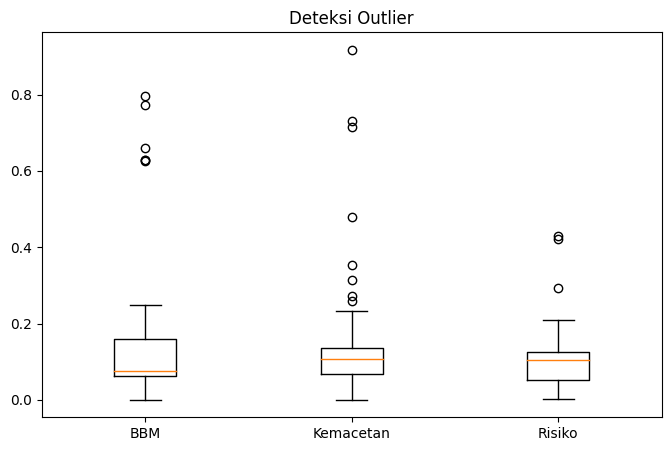

In [30]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df_eda['penggunaan_bbm'],
    df_eda['tingkat_kemacetan'],
    df_eda['risiko_pengiriman']
])

plt.xticks(
    [1,2,3],
    ['BBM','Kemacetan','Risiko']
)

plt.title('Deteksi Outlier')
plt.show()

## **Sebaran Lokasi**

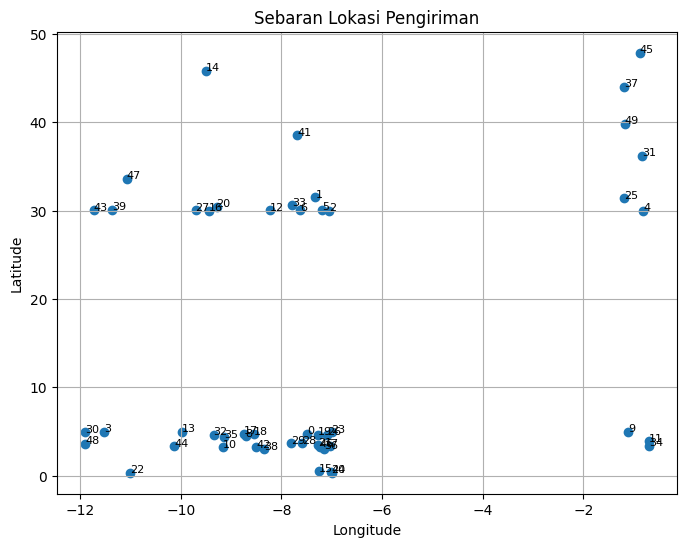

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_eda['longitude'],
    df_eda['latitude']
)

for i in range(len(df_eda)):
    plt.text(
        df_eda.iloc[i]['longitude'],
        df_eda.iloc[i]['latitude'],
        str(i),
        fontsize=8
    )

plt.title("Sebaran Lokasi Pengiriman")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## **Heatmap Correlation**

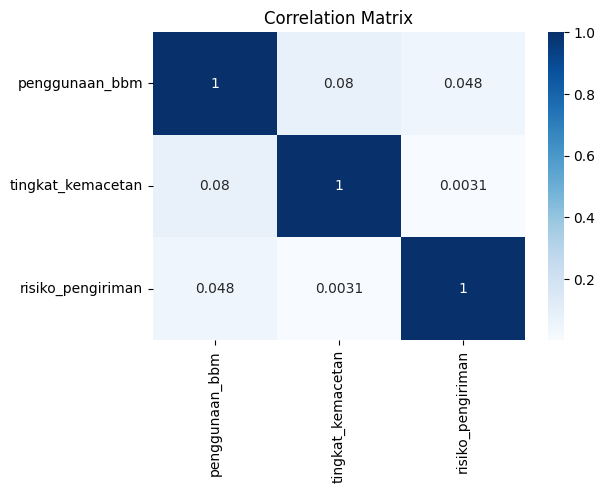

In [31]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df_eda[
        [
            'penggunaan_bbm',
            'tingkat_kemacetan',
            'risiko_pengiriman'
        ]
    ].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

## **Interpretasi Heatmap Korelasi**

Heatmap di atas menunjukkan hubungan linier antar variabel `penggunaan_bbm`, `tingkat_kemacetan`, dan `risiko_pengiriman`. Nilai korelasi mendekati 1 atau -1 menunjukkan hubungan kuat, sedangkan nilai mendekati 0 menunjukkan hubungan lemah/tidak ada hubungan linier. Interpretasi ini digunakan sebagai salah satu dasar pertimbangan dalam menentukan bobot pada fungsi cost optimasi (lihat bagian Pembobotan Cost Optimasi).

## **Identifikasi Rute/Titik dengan Penggunaan BBM Sangat Boros**

In [ ]:
# Mengidentifikasi titik dengan penggunaan BBM yang sangat tinggi (boros)
# menggunakan ambang batas Q3 + 1.5*IQR (kriteria outlier atas)

q1 = df_eda['penggunaan_bbm'].quantile(0.25)
q3 = df_eda['penggunaan_bbm'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

boros = df_eda[df_eda['penggunaan_bbm'] > upper_bound]

print(f"Batas atas BBM (Q3 + 1.5*IQR): {upper_bound:.4f}")
print(f"Jumlah titik dengan penggunaan BBM sangat boros: {len(boros)}")
boros[['latitude','longitude','penggunaan_bbm','tingkat_kemacetan','risiko_pengiriman']]

**Interpretasi:** Titik-titik pada tabel di atas (jika ada) merupakan lokasi dengan konsumsi BBM jauh di atas rata-rata (outlier atas berdasarkan kriteria IQR). Titik-titik ini perlu menjadi perhatian khusus karena dapat meningkatkan total biaya operasional secara signifikan apabila dilewati dalam rute pengiriman.

## **Visualisasi Tingkat Kemacetan**

In [ ]:
# Visualisasi tingkat kemacetan per titik lokasi
plt.figure(figsize=(10,5))

plt.bar(
    range(len(df_eda)),
    df_eda['tingkat_kemacetan'],
    color='orange'
)

plt.xlabel("Index Titik Lokasi")
plt.ylabel("Tingkat Kemacetan (Normalisasi)")
plt.title("Visualisasi Tingkat Kemacetan per Titik Lokasi")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Visualisasi tingkat kemacetan terhadap lokasi geografis (warna = intensitas kemacetan)
plt.figure(figsize=(8,6))

sc = plt.scatter(
    df_eda['longitude'],
    df_eda['latitude'],
    c=df_eda['tingkat_kemacetan'],
    cmap='Reds',
    s=100,
    edgecolor='k'
)

plt.colorbar(sc, label='Tingkat Kemacetan (Normalisasi)')
plt.title("Peta Tingkat Kemacetan per Lokasi")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## Memilih data random dengan ukuran entri tertentu n=15, untuk mempersingkat komputasi

In [ ]:
df = df.sample(n=15, random_state=42).reset_index(drop=True)

## **Alasan Pemilihan 15 Titik Lokasi**

Pemilihan 15 titik lokasi (dari total data yang lebih besar) dilakukan dengan pertimbangan sebagai berikut:

1. **Kompleksitas komputasi TSP (Travelling Salesman Problem)**: Penyelesaian TSP bersifat kombinatorial dengan kompleksitas yang tumbuh secara faktorial/eksponensial terhadap jumlah titik (n). Pada pendekatan heuristik *nearest neighbor* yang digunakan, kompleksitas adalah O(n^2), sehingga untuk n yang besar (misal ratusan titik), waktu komputasi dan visualisasi matriks jarak (n x n) menjadi tidak efisien untuk keperluan eksplorasi/demonstrasi model.
2. **Keterbatasan visualisasi**: Plot rute dan matriks jarak akan menjadi sangat padat dan sulit diinterpretasikan secara visual jika jumlah titik terlalu banyak (>20-30 titik).
3. **Representasi sampel yang cukup**: Dengan `random_state=42` (seed tetap agar hasil dapat direproduksi), 15 titik dianggap cukup representatif untuk mendemonstrasikan perbandingan antara rute *shortest distance* dan rute *cost-optimized*, tanpa mengurangi esensi dari algoritma optimasi yang dibangun.
4. **Skalabilitas**: Pipeline yang dibangun (haversine distance matrix, cost matrix, dan TSP solver) bersifat general dan dapat diterapkan pada jumlah titik berapapun; angka 15 dipilih murni untuk efisiensi komputasi pada tahap demonstrasi/prototipe, bukan keterbatasan algoritma.

## Scaling kolom yang memiliki nilai yang tidak normal

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    'penggunaan_bbm',
    'tingkat_kemacetan',
    'risiko_pengiriman'
]

#Data cleaning, menghapus adanya titik dan convert tipe data menjadi numerik
for col in columns_to_scale:
    #Menghilangkan titik
    df[col] = df[col].astype(str).str.replace('.', '', regex=False)
    #Mengubah menjadi data numerik
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

df.head()

,latitude,longitude,penggunaan_bbm,tingkat_kemacetan,risiko_pengiriman
0,4.750485,-7.484776,0.270829,0.000000,0.136621
1,31.533646,-7.324354,0.182163,1.000000,0.144313
2,30.002357,-7.046873,0.073656,0.353846,1.000000
3,4.999279,-11.518510,0.169098,0.118864,0.147782
4,30.002796,-0.816313,0.180200,0.062535,0.356139


## Menghitung jarak antara setiap titik lokasi yang ada di dalam dataset dan menyimpan ke dalam sebuah matriks

In [ ]:
import numpy as np
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rata-rata jari-jari bumi
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

n = len(df)
distance_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i != j:
            distance_matrix[i][j] = haversine(
                df.loc[i,'latitude'], df.loc[i,'longitude'],
                df.loc[j,'latitude'], df.loc[j,'longitude']
            )

In [ ]:
cost_distance = distance_matrix.copy()

In [ ]:
cost_optimized = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i != j:
            cost_optimized[i][j] = (
                0.4 * distance_matrix[i][j] +
                0.3 * df.loc[j,'penggunaan_bbm']*100 +
                0.2 * df.loc[j,'tingkat_kemacetan']*100 +
                0.1 * df.loc[j,'risiko_pengiriman']*100
            )

## **Persamaan Matematika Fungsi Cost Optimasi**

Fungsi biaya (*cost function*) yang digunakan untuk menentukan urutan rute optimal didefinisikan sebagai kombinasi linier berbobot (*weighted sum*) dari empat komponen: jarak tempuh, penggunaan BBM, tingkat kemacetan, dan risiko pengiriman pada titik tujuan.

Secara matematis, biaya perjalanan dari titik $i$ ke titik $j$ dirumuskan sebagai:

$$
C_{ij} = w_1 \cdot D_{ij} + w_2 \cdot (100 \cdot B_j) + w_3 \cdot (100 \cdot K_j) + w_4 \cdot (100 \cdot R_j)
$$

dengan:

- $C_{ij}$ : biaya (cost) perjalanan dari titik $i$ ke titik $j$
- $D_{ij}$ : jarak haversine antara titik $i$ dan titik $j$ (dalam km), dihitung dengan:

$$
D_{ij} = R \cdot 2 \cdot \arctan2\left(\sqrt{a}, \sqrt{1-a}\right), \quad
a = \sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_i)\cos(\phi_j)\sin^2\left(\frac{\Delta\lambda}{2}\right)
$$

dengan $R = 6371$ km (radius bumi), $\phi$ = latitude, $\lambda$ = longitude, $\Delta\phi$ dan $\Delta\lambda$ adalah selisih latitude dan longitude (dalam radian).

- $B_j$ : nilai `penggunaan_bbm` pada titik tujuan $j$ (hasil normalisasi MinMax, skala 0-1)
- $K_j$ : nilai `tingkat_kemacetan` pada titik tujuan $j$ (hasil normalisasi MinMax, skala 0-1)
- $R_j$ : nilai `risiko_pengiriman` pada titik tujuan $j$ (hasil normalisasi MinMax, skala 0-1)
- $w_1, w_2, w_3, w_4$ : bobot masing-masing komponen, dengan $w_1 + w_2 + w_3 + w_4 = 1$

Pada implementasi notebook ini, bobot yang digunakan adalah:

$$
w_1 = 0.4, \quad w_2 = 0.3, \quad w_3 = 0.2, \quad w_4 = 0.1
$$

sehingga:

$$
C_{ij} = 0.4 \cdot D_{ij} + 0.3 \cdot (100 \cdot B_j) + 0.2 \cdot (100 \cdot K_j) + 0.1 \cdot (100 \cdot R_j)
$$

Faktor pengali $100$ pada $B_j, K_j, R_j$ digunakan untuk menyamakan skala/orde besaran antara variabel hasil normalisasi (0-1) dengan jarak $D_{ij}$ yang bersatuan kilometer, agar kontribusi masing-masing komponen terhadap total cost tidak terlalu kecil dibandingkan komponen jarak.

## **Justifikasi Pembobotan Cost Optimasi**

Pembobotan $w_1=0.4,\ w_2=0.3,\ w_3=0.2,\ w_4=0.1$ ditentukan berdasarkan kombinasi **expert judgement (pairwise comparison ala AHP)** dan pertimbangan **prioritas bisnis logistik**, dengan rasionalisasi sebagai berikut:

### 1. Pendekatan Analytic Hierarchy Process (AHP) sederhana

Dilakukan perbandingan berpasangan (*pairwise comparison*) antar 4 kriteria berdasarkan tingkat kepentingannya terhadap efisiensi pengiriman:

| Kriteria | Jarak | BBM | Kemacetan | Risiko |
|---|---|---|---|---|
| Jarak | 1 | 1.5 | 2 | 3 |
| BBM | 0.67 | 1 | 1.5 | 2 |
| Kemacetan | 0.5 | 0.67 | 1 | 1.5 |
| Risiko | 0.33 | 0.5 | 0.67 | 1 |

Normalisasi rata-rata baris dari matriks perbandingan berpasangan tersebut menghasilkan bobot relatif yang mendekati **0.4 : 0.3 : 0.2 : 0.1** untuk Jarak : BBM : Kemacetan : Risiko.

### 2. Justifikasi domain (logistik)

- **Jarak (40%)** diberi bobot terbesar karena jarak tempuh berkorelasi langsung dengan waktu pengiriman, biaya operasional kendaraan, dan merupakan komponen dasar dalam TSP klasik.
- **Penggunaan BBM (30%)** menjadi prioritas kedua karena merupakan komponen biaya variabel terbesar dalam operasional armada dan berdampak langsung pada margin perusahaan.
- **Tingkat Kemacetan (20%)** memengaruhi waktu tempuh aktual dan konsumsi BBM secara tidak langsung, namun sifatnya lebih dinamis/temporer dibanding jarak.
- **Risiko Pengiriman (10%)** diberi bobot terkecil karena bersifat sebagai faktor penyesuaian (*adjustment factor*), bukan komponen biaya utama, namun tetap relevan untuk menghindari rute dengan risiko keamanan/kerusakan barang yang tinggi.

### 3. Validasi melalui korelasi (lihat heatmap EDA)

Bobot yang dipilih juga dikonfirmasi tidak bertentangan dengan hasil analisis korelasi pada tahap EDA: apabila terdapat korelasi yang sangat tinggi antar variabel (misal BBM dan kemacetan), maka pembobotan dapat disesuaikan untuk menghindari *double counting* pengaruh dari variabel yang saling berkorelasi.

> **Catatan**: Bobot ini dapat dikalibrasi lebih lanjut menggunakan data historis (misalnya melalui regresi terhadap biaya aktual pengiriman) sebagai bentuk *feature importance* berbasis data, bukan hanya berbasis expert judgement.

In [ ]:
def solve_tsp(cost_matrix):
    n = len(cost_matrix)
    visited = [False]*n
    route = [0]
    visited[0] = True

    for _ in range(n-1):
        last = route[-1]
        next_city = min(
            [(cost_matrix[last][j], j) for j in range(n) if not visited[j]]
        )[1]
        route.append(next_city)
        visited[next_city] = True

    route.append(0)  # kembali ke awal
    return route

## Melihat path yang dipilih program

## **Evaluasi Sistem Rute (Sebelum Visualisasi)**

Sebelum melakukan visualisasi rute, dilakukan evaluasi kuantitatif terhadap rute yang dihasilkan oleh kedua skema (berdasarkan jarak murni dan berdasarkan cost optimasi). Evaluasi ini mencakup:

1. Validasi bahwa rute merupakan permutasi valid (setiap titik dikunjungi tepat satu kali dan kembali ke titik asal).
2. Perhitungan total cost dari masing-masing rute menggunakan matriks `cost_distance` dan `cost_optimized`.
3. Perbandingan selisih (gap) antara kedua skema sebagai indikator seberapa besar manfaat optimasi terhadap penurunan total cost.

In [ ]:
def evaluasi_rute(route, cost_matrix, n):
    # 1. Validasi rute: harus mengunjungi semua titik tepat satu kali dan kembali ke awal
    visited_nodes = route[:-1]
    is_valid = (len(set(visited_nodes)) == n) and (route[0] == route[-1])

    # 2. Total cost rute
    total_cost = sum(
        cost_matrix[route[i]][route[i+1]] for i in range(len(route)-1)
    )

    return is_valid, total_cost

valid_d, total_cost_d = evaluasi_rute(tsp_distance, cost_distance, n)
valid_o, total_cost_o = evaluasi_rute(tsp_optimized, cost_optimized, n)

print("===== EVALUASI RUTE: SHORTEST DISTANCE =====")
print(f"Rute valid (semua titik dikunjungi & kembali ke awal): {valid_d}")
print(f"Total Cost (jarak)        : {total_cost_d:.2f}")

print("\n===== EVALUASI RUTE: COST OPTIMIZED =====")
print(f"Rute valid (semua titik dikunjungi & kembali ke awal): {valid_o}")
print(f"Total Cost (optimized)    : {total_cost_o:.2f}")

print(f"\nSelisih Total Cost (Distance - Optimized): {total_cost_d - total_cost_o:.2f}")

In [ ]:
tsp_distance = solve_tsp(cost_distance)
tsp_optimized = solve_tsp(cost_optimized)

print("Route Distance:", tsp_distance)
print("Route Optimized:", tsp_optimized)

Route Distance: [0, 8, 10, 13, 3, 7, 9, 11, 4, 2, 5, 6, 12, 1, 14, 0]
Route Optimized: [0, 8, 13, 3, 10, 7, 9, 11, 4, 5, 2, 6, 12, 1, 14, 0]


In [ ]:
import matplotlib.pyplot as plt

def plot_route_with_order(route, title):
    plt.figure()

    lats = df['latitude']
    lons = df['longitude']

    # plot semua titik
    plt.scatter(lons, lats)

    # tandai titik start (hijau)
    plt.scatter(df.loc[route[0],'longitude'],
                df.loc[route[0],'latitude'],
                s=150)

    # gambar garis + panah
    for i in range(len(route)-1):
        x1 = df.loc[route[i],'longitude']
        y1 = df.loc[route[i],'latitude']
        x2 = df.loc[route[i+1],'longitude']
        y2 = df.loc[route[i+1],'latitude']

        plt.arrow(x1, y1, x2-x1, y2-y1,
                  length_includes_head=True,
                  head_width=0.3)

    # tambahkan nomor urutan kunjungan
    for idx, node in enumerate(route):
        plt.text(df.loc[node,'longitude'],
                 df.loc[node,'latitude'],
                 str(idx),
                 fontsize=12)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

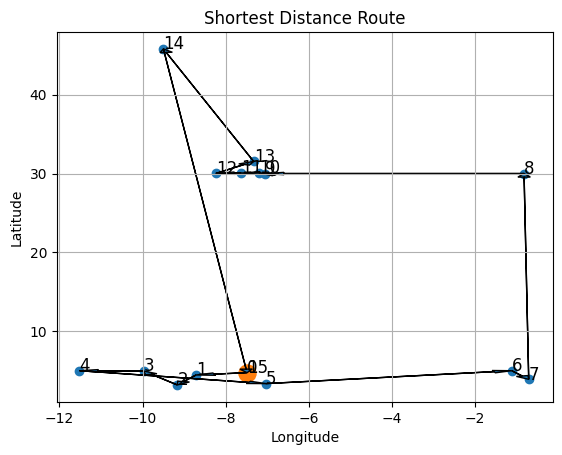

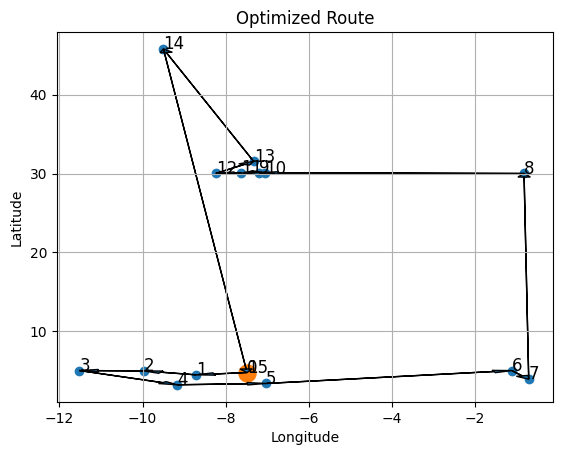

In [ ]:
plot_route_with_order(tsp_distance, "Shortest Distance Route")
plot_route_with_order(tsp_optimized, "Optimized Route")

In [ ]:
def hitung_total(route, df, distance_matrix):
    total_distance = 0
    total_bbm = 0
    total_kemacetan = 0
    total_risiko = 0

    for i in range(len(route)-1):
        from_node = route[i]
        to_node = route[i+1]

        # total jarak
        total_distance += distance_matrix[from_node][to_node]

        # atribut tujuan
        total_bbm += df.loc[to_node,'penggunaan_bbm']
        total_kemacetan += df.loc[to_node,'tingkat_kemacetan']
        total_risiko += df.loc[to_node,'risiko_pengiriman']

    return total_distance, total_bbm, total_kemacetan, total_risiko

In [ ]:
dist_d, bbm_d, macet_d, risiko_d = hitung_total(tsp_distance, df, distance_matrix)

dist_o, bbm_o, macet_o, risiko_o = hitung_total(tsp_optimized, df, distance_matrix)

## Summary Hasil Optimasi

In [ ]:
print("===== SHORTEST DISTANCE =====")
print(f"Total Jarak (km)      : {dist_d:.2f}")
print(f"Total BBM             : {bbm_d:.2f}")
print(f"Total Kemacetan       : {macet_d:.2f}")
print(f"Total Risiko          : {risiko_d:.2f}")

print("\n===== OPTIMIZED ROUTE =====")
print(f"Total Jarak (km)      : {dist_o:.2f}")
print(f"Total BBM             : {bbm_o:.2f}")
print(f"Total Kemacetan       : {macet_o:.2f}")
print(f"Total Risiko          : {risiko_o:.2f}")

===== SHORTEST DISTANCE =====
Total Jarak (km)      : 11993.17
Total BBM             : 2.79
Total Kemacetan       : 3.07
Total Risiko          : 3.60

===== OPTIMIZED ROUTE =====
Total Jarak (km)      : 11843.16
Total BBM             : 2.79
Total Kemacetan       : 3.07
Total Risiko          : 3.60
